# Phase 2: TF-IDF + LSA + K-Means topic clustering

This notebook starts from `reviews_with_sentiment.csv`, generated at the end of Phase 1.

The reusable clustering pipeline is implemented in `src/clustering/tfidf_kmeans.py`:

1. TF-IDF text features
2. TruncatedSVD for Latent Semantic Analysis
3. L2 normalization
4. K-Means clustering

The notebook is responsible only for orchestration, reporting, manual interpretation, and saving outputs.


In [1]:
# locate the project root
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/karima/Ironhack-challenges/voxforge-ai-review-analytics


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data.load import load_csv
from src.clustering.tfidf_kmeans import (
    add_topic_labels,
    cluster_size_summary,
    create_svd_coordinates,
    evaluate_cluster_counts,
    fit_topic_model,
    representative_reviews,
    save_topic_model,
    top_terms,
    topic_sentiment_summary,
)

from src.config import (
    CLUSTERED_REVIEWS_PATH,
    CLUSTERING_MODELS_DIR,
    CLUSTERING_RESULTS_DIR,
    ENRICHED_REVIEWS_PATH,
    DEFAULT_CLUSTER_COUNTS,
    SVD_COMPONENTS,
    DEFAULT_N_CLUSTERS,
    create_project_directories,
)

from src.clustering.labeling import (
    build_stop_words, suggest_topic_names, top_terms_to_mapping,
    cluster_quality_report, topic_sentiment_hooks,
)

create_project_directories()

TEXT_COLUMN = "classical_text"
MODEL_FILENAME = "tfidf_svd_kmeans.joblib"


## Load the enriched review data

All input and output paths continue to come from `src/config.py`.


In [3]:
from pathlib import Path

for base in [
    Path("/content/voxforge-ai-review-analytics"),
    Path.cwd(),
    Path("/Users/karima/Ironhack-challenges/voxforge-ai-review-analytics"),
]:
    matches = list(base.rglob("reviews_with_sentiment.csv"))
    if matches:
        print("FOUND:", matches[0])
        break
else:
    print("No reviews_with_sentiment.csv found.")

FOUND: /Users/karima/Ironhack-challenges/voxforge-ai-review-analytics/data/processed/reviews_with_sentiment.csv


In [4]:
reviews = load_csv(ENRICHED_REVIEWS_PATH)

if TEXT_COLUMN not in reviews.columns:
    raise KeyError(
        f"Missing clustering text column: {TEXT_COLUMN!r}. "
        f"Available columns: {list(reviews.columns)}"
    )

model_data = reviews.dropna(subset=[TEXT_COLUMN]).copy()
model_data[TEXT_COLUMN] = model_data[TEXT_COLUMN].astype(str).str.strip()
model_data = (
    model_data[model_data[TEXT_COLUMN].str.len().gt(0)]
    .reset_index(drop=True)
)

print(f"Rows available for clustering: {len(model_data):,}")


INFO - Loaded 47279 rows


Rows available for clustering: 47,276


## 1. Compare a small range of cluster counts

Silhouette and inertia are diagnostic signals, not automatic selectors. The final value of K is also judged through top terms, representative reviews, cluster sizes, and business interpretability.


,n_clusters,inertia,silhouette_score,svd_components,svd_explained_variance_ratio
0,2,42123.636719,0.034774,100,0.212262
1,3,40973.550781,0.035031,100,0.212262
2,4,40079.589844,0.042233,100,0.212262
3,5,39270.675781,0.048697,100,0.212262
4,6,38526.937500,0.051260,100,0.212262
5,7,37865.406250,0.053701,100,0.212262
6,8,37325.320312,0.055489,100,0.212262
7,9,36806.445312,0.059641,100,0.212262
8,10,36320.843750,0.062432,100,0.212262


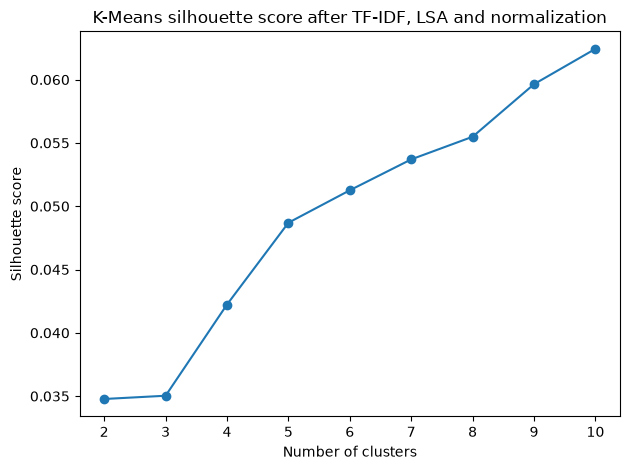

In [5]:
cluster_scores = evaluate_cluster_counts(
    model_data[TEXT_COLUMN],
    cluster_counts=DEFAULT_CLUSTER_COUNTS,
    svd_components=SVD_COMPONENTS,
)

cluster_scores.to_csv(
    CLUSTERING_RESULTS_DIR / "cluster_count_evaluation.csv",
    index=False,
)

display(cluster_scores)

ax = cluster_scores.plot(
    x="n_clusters",
    y="silhouette_score",
    marker="o",
    legend=False,
)
ax.set_title("K-Means silhouette score after TF-IDF, LSA and normalization")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

## 2. Fit the selected cluster count

The scores are interpreted alongside qualitative cluster evidence. If the curve remains low and flat, the selected K is justified primarily by interpretability rather than by a decisive metric optimum.


In [6]:
N_CLUSTERS = DEFAULT_N_CLUSTERS

run = fit_topic_model(
    model_data[TEXT_COLUMN],
    n_clusters=N_CLUSTERS,
    svd_components=SVD_COMPONENTS,
)

print(f"Final silhouette score: {run['silhouette_score']:.4f}")
print(
    "SVD explained variance ratio: "
    f"{run['explained_variance_ratio']:.4f}"
)

terms = top_terms(run, top_n=12)
representatives = representative_reviews(
    model_data[TEXT_COLUMN],
    run,
    reviews_per_cluster=5,
)
cluster_sizes = cluster_size_summary(run)

terms.to_csv(
    CLUSTERING_RESULTS_DIR / "top_terms.csv",
    index=False,
)
representatives.to_csv(
    CLUSTERING_RESULTS_DIR / "representative_reviews.csv",
    index=False,
)
cluster_sizes.to_csv(
    CLUSTERING_RESULTS_DIR / "cluster_sizes.csv",
    index=False,
)

display(
    terms.groupby("cluster_id")["term"]
    .apply(list)
    .to_frame(name="top_terms")
)
display(representatives)
display(cluster_sizes)


Final silhouette score: 0.0513
SVD explained variance ratio: 0.2123


,top_terms
cluster_id,
0,"[kindle, book, read, reading, love, reader, gr..."
1,"[tablet, great tablet, great, kid, good, love,..."
2,"[battery, good, brand, great battery, great, l..."
3,"[echo, alexa, music, love, fun, great, home, s..."
4,"[great, good, work, love, tv, gift, work great..."
5,"[easy, easy use, use, great, set, love, easy s..."


,cluster_id,rank,review_index,review_text,distance_to_centroid
0,0,1,5655,great serious annotation scripture study main ...,0.661419
1,0,2,13368,use reading bonus purchased previously kindle ...,0.669122
2,0,3,18455,kindle paperwhite kindle best product differen...,0.672593
3,0,4,11650,first kindle looked getting kindle year looked...,0.674187
4,0,5,19292,love kindle hardcore hardback book reader alwa...,0.676254
5,1,1,15768,great tablet goog tablet bad part creating pro...,0.656213
6,1,2,2344,great tablet price tablet absolute steal never...,0.668053
7,1,3,3768,great tablet drop gb card beast tablet especia...,0.668152
8,1,4,11738,color great reliable tablet three fire tablet ...,0.668903
9,1,5,16809,great tablet tablet ideal kid come great case ...,0.670035


,cluster_id,review_count,percentage
0,0,5456,11.54
1,1,8466,17.91
2,2,5561,11.76
3,3,5807,12.28
4,4,18032,38.14
5,5,3954,8.36


## 3. Assign human-readable topic names

Cluster IDs are arbitrary and can change after retraining. Inspect the newly generated top terms and representative reviews before finalizing this mapping.

The initial names below reflect the previous run and must be checked against the new outputs.


In [7]:
term_map = top_terms_to_mapping(terms)
TOPIC_NAMES = {cluster_id: f"topic_{cluster_id}" for cluster_id in range(N_CLUSTERS)}


expected_ids = set(range(N_CLUSTERS))
provided_ids = set(TOPIC_NAMES)

if provided_ids != expected_ids:
    raise ValueError(
        "TOPIC_NAMES must contain exactly one name for every cluster. "
        f"Expected {sorted(expected_ids)}, received {sorted(provided_ids)}."
    )

clustered = add_topic_labels(
    model_data,
    run,
    TOPIC_NAMES,
)

clustered.to_csv(
    CLUSTERED_REVIEWS_PATH,
    index=False,
)

qa = cluster_quality_report(term_map, representatives, sizes=cluster_sizes, names=TOPIC_NAMES)
display(qa)
display(topic_sentiment_hooks(clustered))

summary = topic_sentiment_summary(clustered)
summary.to_csv(
    CLUSTERING_RESULTS_DIR / "topic_sentiment_summary.csv",
    index=False,
)

display(summary)


,cluster_id,name,size,top_terms,sample_reviews,coherent,pct
0,0,topic_0,5456,"kindle, book, read, reading, love, reader, gre...",great serious annotation scripture study main ...,True,11.54
1,1,topic_1,8466,"tablet, great tablet, great, kid, good, love, ...",great tablet goog tablet bad part creating pro...,True,17.91
2,2,topic_2,5561,"battery, good, brand, great battery, great, lo...",five star battery cheaper price yes please | a...,True,11.76
3,3,topic_3,5807,"echo, alexa, music, love, fun, great, home, sp...",entertaining love echo one living room upstair...,True,12.28
4,4,topic_4,18032,"great, good, work, love, tv, gift, work great,...",five star ordered | five star | two star excel...,False,38.14
5,5,topic_5,3954,"easy, easy use, use, great, set, love, easy se...",great buy easy use smaller version easy adjust...,False,8.36


,topic,reviews,positive_pct,neutral_pct,negative_pct,hook
0,topic_2,5561,75.11,7.59,17.30,Highest complaint rate (17% negative) — lead t...
1,topic_4,18032,86.34,8.69,4.97,Mixed reception (86% positive / 5% negative) —...
2,topic_0,5456,91.70,4.56,3.74,Mixed reception (92% positive / 4% negative) —...
3,topic_1,8466,84.11,13.21,2.68,Mixed reception (84% positive / 3% negative) —...
4,topic_3,5807,91.91,6.23,1.86,Mixed reception (92% positive / 2% negative) —...
5,topic_5,3954,96.23,2.88,0.89,Strongly liked (96% positive) — frame as a con...


,topic_name,sentiment_label,review_count,topic_review_count,sentiment_percentage
0,topic_0,positive,5161,5456,94.59
1,topic_0,neutral,162,5456,2.97
2,topic_0,negative,133,5456,2.44
3,topic_1,positive,7793,8466,92.05
4,topic_1,neutral,478,8466,5.65
5,topic_1,negative,195,8466,2.30
6,topic_2,positive,4607,5561,82.84
7,topic_2,negative,679,5561,12.21
8,topic_2,neutral,275,5561,4.95
9,topic_3,positive,5527,5807,95.18


## 4. Two-dimensional visualization

This projection is used only for visualization. It does not retrain or change the final clusters.


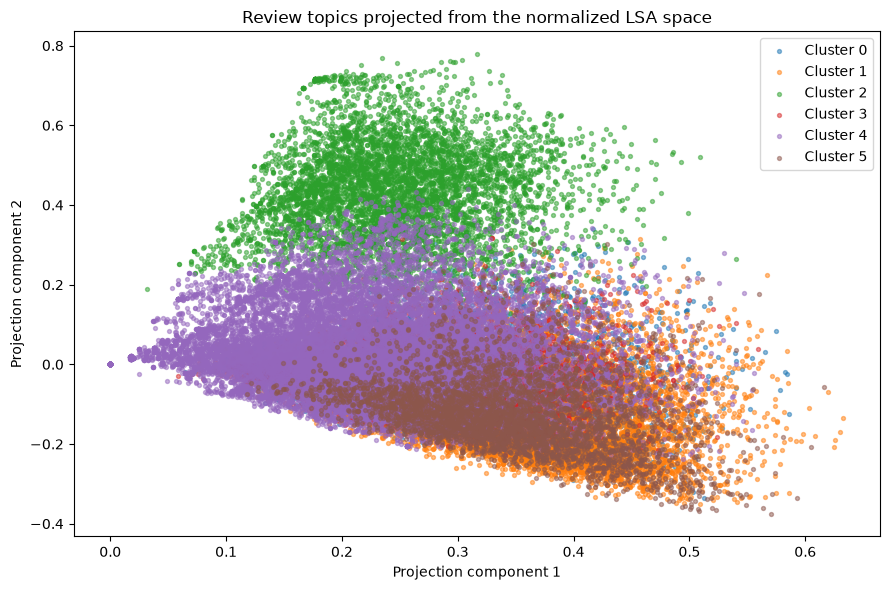

In [10]:
coordinates = create_svd_coordinates(run)

coordinates.to_csv(
    CLUSTERING_RESULTS_DIR / "svd_coordinates.csv",
    index=False,
)

plt.figure(figsize=(9, 6))

for cluster_id, group in coordinates.groupby("cluster_id"):
    plt.scatter(
        group["component_1"],
        group["component_2"],
        s=8,
        alpha=0.5,
        label=f"Cluster {cluster_id}",
    )

plt.title("Review topics projected from the normalized LSA space")
plt.xlabel("Projection component 1")
plt.ylabel("Projection component 2")
plt.legend()
plt.tight_layout()

plt.savefig(
    CLUSTERING_RESULTS_DIR / "topic_clusters_svd.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## 5. Save the reusable topic model

The artifact contains the fitted TF-IDF vectorizer, SVD transformer, normalizer, K-Means model, topic names, and compact metadata. Training matrices are intentionally excluded.


In [11]:
model_path = save_topic_model(
    run,
    CLUSTERING_MODELS_DIR / MODEL_FILENAME,
    topic_names=TOPIC_NAMES,
)

print("Saved clustered reviews:", CLUSTERED_REVIEWS_PATH)
print("Saved topic model:", model_path)


Saved clustered reviews: /Users/karima/Ironhack-challenges/voxforge-ai-review-analytics/data/processed/reviews_with_sentiment_and_topics.csv
Saved topic model: /Users/karima/Ironhack-challenges/voxforge-ai-review-analytics/models/clustering/tfidf_svd_kmeans.joblib


## Key learning from the first implementation of clustering

- We evaluated several values of K using the Elbow Method. K=5 provided a good trade-off between cluster separation and interpretability. The resulting clusters corresponded to meaningful customer-review themes.
- silhouette thresholds such as 0.5 = strong are only rough rules. Text datasets with short, sparse reviews frequently produce much lower values than conventional tabular clustering datasets.

k=8 scoring 0.0094
k=6 scoring close to 0.009
k=2 scoring 0.0067

Silhouette scores remained very low and relatively flat across the tested values of K, indicating substantial overlap between review clusters. Six clusters were therefore selected primarily for interpretability and their ability to reveal recognizable product-related themes rather than because of a decisive quantitative optimum.
- Correct real defect: rating-word leakage. The current preprocessing removes ordinary English stop words, but terms such as:
star
stars
five
four
three
two
one
remain in the corpus. Because many review bodies contain rating phrases, KMeans treats them as meaningful topic signals ===> We should remove those as custom stopwords
- The proposed improved pipeline is:

                Review text
                    ↓
                TF-IDF
                    ↓
                TruncatedSVD, approximately 100 dimensions
                    ↓
                L2 normalization
                    ↓
                KMeans
    The normalization is important because after L2 normalization, Euclidean distance becomes closely related to cosine similarity.

## Experiment 2 Key Learnings: Review text -> TF-IDF -> SVD -> L2 normalization -> Kmeans
- The SVD step worked. the silhouette went from ~0.009 to ~0.05 across the board (0.0515 at k=6) — roughly a 5× improvement — purely from clustering in the reduced 100-dim space instead of raw sparse TF-IDF. This change has moved the needle.

- Separation is still weak, 0.05 is better but still low on the −1→+1 scale, and two facts explain it: the silhouette curve still rises monotonically to k=10 with no elbow (the metric alone would push you to more clusters), and the 100 SVD components capture only 21% of the variance. Review text is genuinely high-entropy and spread out, there's no tight underlying structure to find. This is a property of short, praise-dominated review text, not a flaw in the pipeline.

- The clearest signal in the data: one giant catch-all. Cluster 0 holds 36% of all reviews (17,187) and its top terms are generic, "great, good, work, love, price." Its centroid-nearest reviews are degenerate fragments: "five star excelente," "facemask facemask," "five star asdfghj", all at identical distance 0.2766, meaning near-duplicates. So a third of the data collapsed into a low information blob that's also absorbing the rating-word junk.

- The topic names are on the wrong clusters, almost every label is misplaced:

Cluster	Actual content      (terms + reviews)	            The assigned name	                    Match?
    0  (17,187)	generic praise + rating-only junk	        Kindle, Fire TV & General Praise	    partial
    1 (9,004)	"great tablet…" → Fire Tablets	            Rating-Only Reviews	                        ✗
    2 (5,519)	"kindle, book, reader…" → Kindle e-readers	Fire Tablets	                            ✗
    3 (5,573)	"battery, brand, long…" → Batteries	        Echo & Alexa Devices	                    ✗
    4 (5,631)	"echo, alexa, music…" → Echo & Alexa	    Ease of Use	                                ✗  
    5 (4,362)	"great product…" → generic product	        Batteries	                                ✗

- The cluster  named "Echo & Alexa" carries 12.3% negative, that's battery behavior (batteries were your most-complained-about category last run), while the cluster named "Batteries" is 95.9% positive, which is generic-praise behavior, not batteries.
The cause is a classic K-Means trap: cluster IDs are arbitrary and change between runs. TOPIC_NAMES dict matches the previous (pre-SVD) run's ordering exactly. When added SVD, the clusters got re-numbered, but the hardcoded names didn't follow. So the labels are stale, not wrong-headed.

Key learnings
- SVD-before-K-Means is the right architecture for text, and it measurably improved separation. Keep it.
- Meaningful product themes genuinely exist even under weak global separation: Fire Tablets, Kindle e-readers, Batteries, and Echo/- Alexa all surface as coherent clusters. That's the real win — four clean categories out of six.
= Generic praise vocabulary dominates the corpus, producing a 36% catch-all plus a second generic "product" cluster. Roughly 45% of the data is low-information.
- Silhouette is the wrong hill to die on here. For short review text it stays low no matter what; the real evidence of cluster quality is the top-terms + representative-reviews inspection.
- K-Means labels aren't stable, any hardcoded ID→name mapping is a latent bug.

## Next steps:
1- Re-derive the topic names from this run. Read this run's top terms and representative reviews and rewrite TOPIC_NAMES to match. To stop it recurring: pin random_state, and ideally auto-suggest names from each cluster's top 3 terms so the labels can never drift from the content again.
3- Decide what to do with the ~45% generic mass. Either raise k so it splits into real products, or explicitly label it "general / uncategorized" and focus Task 3 articles on the four solid product clusters. Both are defensible, just be deliberate.
4- Validate qualitatively and say so in the write-up. Frame it honestly: silhouette is weak (expected for short-text TF-IDF), so k was chosen for interpretability, and cluster quality is evidenced by coherent top terms and representative reviews per category.
5- Carry the sentiment-by-topic insight into Task 3. Once names are correct, "batteries are the most-complained-about category" is exactly the hook the recommendation articles need.


